In [34]:
!pip install joblib einops

In [35]:
import joblib

In [71]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch import optim

import numpy as np
import scipy.io as sio
import scipy.signal as signal

from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.metrics import (confusion_matrix, accuracy_score,
                              classification_report, cohen_kappa_score)
from sklearn.preprocessing import MinMaxScaler

from einops import rearrange, repeat
from einops.layers.torch import Rearrange

import time
import os
from tqdm import tqdm
import matplotlib.pyplot as plt
import matplotlib.colors as colors
from matplotlib.patches import Patch
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

print("All imports successful!")

All imports successful!


In [38]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

if torch.cuda.is_available():
    total     = torch.cuda.get_device_properties(0).total_memory / 1024**3
    allocated = torch.cuda.memory_allocated() / 1024**3
    free      = total - allocated
    print(f"GPU      : {torch.cuda.get_device_name(0)}")
    print(f"Total    : {total:.2f} GB")
    print(f"Free     : {free:.2f} GB")

Using device: cuda:0
GPU      : Tesla T4
Total    : 14.56 GB
Free     : 14.42 GB


In [73]:
# ── Dataset ───────────────────────────────────────────────────────────────────
class_num      = 16     # Indian Pines has 16 classes
patch_size     = 17
pca_components = 30

# ── Training ──────────────────────────────────────────────────────────────────
N_RUNS      = 2
EPOCH       = 50        # pre-train runs for EPOCH*2 internally
batch_size  = 64        # T4-safe; contrastive loader uses this too
                         # (two views → effectively 128 samples in VRAM)
ratio_self  = 0.5       # fraction used for pre-training split
ratio_fine  = 0.20     # fraction used for fine-tuning

# ── Model ─────────────────────────────────────────────────────────────────────
mask_ratio    = 0.5
encoder_depth = 8
decoder_depth = 2

# ── Contrastive Learning ──────────────────────────────────────────────────────
proj_dim            = 128
temperature         = 0.2    # raised from 0.07 → better for small batches
                              # NT-Xent with batch=64 needs larger temperature
contrastive_weight  = 0.3    # λ starts gentle; curriculum will ramp it up
cl_warmup_epochs    = 10     # epochs before contrastive loss kicks in
cl_max_weight       = 0.5    # final λ after warm-up

# ── File Paths ────────────────────────────────────────────────────────────────
train_path = '/kaggle/working/net_ip_train.pkl'
fine_path  = '/kaggle/working/net_ip_fine.pkl'
data_path  = '/kaggle/input/datasets/sanjaykumar31/hsi-dataset/Indian_pines_corrected.mat'
label_path = '/kaggle/input/datasets/sanjaykumar31/hsi-dataset/Indian_pines_gt.mat'

'''# ── Dataset ───────────────────────────────────────────────────────────────────
class_num      = 9      # Pavia University has 9 classes
patch_size     = 13     # smaller patch works better for urban scenes
pca_components = 20     # fewer bands → reduce PCA components

# ── Training ──────────────────────────────────────────────────────────────────
N_RUNS      = 2
EPOCH       = 50
batch_size  = 64

ratio_self  = 0.5
ratio_fine  = 0.10      # smaller labeled data works well in PaviaU

# ── Model ─────────────────────────────────────────────────────────────────────
mask_ratio    = 0.5
encoder_depth = 6        # slightly reduce → faster + enough for PaviaU
decoder_depth = 2

# ── Contrastive Learning ──────────────────────────────────────────────────────
proj_dim            = 128
temperature         = 0.3    # slightly higher → helps smaller spectral diversity
contrastive_weight  = 0.3
cl_warmup_epochs    = 10
cl_max_weight       = 0.5

# ── File Paths ────────────────────────────────────────────────────────────────
train_path = '/kaggle/working/net_pu_train.pkl'
fine_path  = '/kaggle/working/net_pu_fine.pkl'

data_path  = '/kaggle/input/datasets/sanjaykumar31/hsi-dataset/PaviaU.mat'
label_path = '/kaggle/input/datasets/sanjaykumar31/hsi-dataset/PaviaU_gt.mat' )
'''

print("PaviaU Configuration loaded!")
print("Configuration loaded!")
print(f"  Batch size        : {batch_size}")
print(f"  Temperature (τ)   : {temperature}")
print(f"  CL warmup epochs  : {cl_warmup_epochs}")
print(f"  CL max weight (λ) : {cl_max_weight}")

PaviaU Configuration loaded!
Configuration loaded!
  Batch size        : 64
  Temperature (τ)   : 0.2
  CL warmup epochs  : 10
  CL max weight (λ) : 0.5


In [74]:
data_mat = sio.loadmat(data_path)
print("Data keys  :", list(data_mat.keys()))
gt_mat = sio.loadmat(label_path)
print("Label keys :", list(gt_mat.keys()))

Data keys  : ['__header__', '__version__', '__globals__', 'indian_pines_corrected']
Label keys : ['__header__', '__version__', '__globals__', 'indian_pines_gt']


In [75]:
def applyPCA(X, numComponents):
    """PCA + save model for consistent inference-time transform."""
    newX = np.reshape(X, (-1, X.shape[2]))
    pca  = PCA(n_components=numComponents, whiten=True)
    newX = pca.fit_transform(newX)
    joblib.dump(pca, "pca_model.pkl")
    return np.reshape(newX, (X.shape[0], X.shape[1], numComponents))


def createImageCubes(X, y, windowSize=5, removeZeroLabels=True):
    """
    Vectorised patch extraction via stride tricks.
    ~100x faster than the original Python double-loop.
    """
    from numpy.lib.stride_tricks import as_strided
    margin  = windowSize // 2
    padded  = np.pad(X, ((margin, margin), (margin, margin), (0, 0)),
                     mode='reflect')
    H, W, C = X.shape
    shape   = (H, W, windowSize, windowSize, C)
    strides = (padded.strides[0], padded.strides[1],
               padded.strides[0], padded.strides[1],
               padded.strides[2])
    patches = np.lib.stride_tricks.as_strided(
        padded, shape=shape, strides=strides)
    patches = patches.reshape(H * W, windowSize, windowSize, C).copy()
    labels  = y.reshape(-1)
    if removeZeroLabels:
        mask    = labels > 0
        patches = patches[mask]
        labels  = labels[mask] - 1
    return patches, labels.astype(np.int64)


def splitTrainTestSet(X, y, testRatio, randomState=345):
    return train_test_split(X, y, test_size=testRatio,
                            random_state=randomState, stratify=y)

print("Preprocessing utilities defined!")

Preprocessing utilities defined!


In [76]:
class TrainDS(Dataset):
    def __init__(self, X, y):
        self.x_data = torch.FloatTensor(X)
        self.y_data = torch.LongTensor(y)
    def __getitem__(self, i): return self.x_data[i], self.y_data[i]
    def __len__(self): return len(self.x_data)


class TestDS(Dataset):
    def __init__(self, X, y):
        self.x_data = torch.FloatTensor(X)
        self.y_data = torch.LongTensor(y)
    def __getitem__(self, i): return self.x_data[i], self.y_data[i]
    def __len__(self): return len(self.x_data)

print("Dataset classes defined!")

Dataset classes defined!


In [77]:
def pair(t):
    return t if isinstance(t, tuple) else (t, t)


class PreNorm(nn.Module):
    def __init__(self, dim, fn):
        super().__init__()
        self.norm = nn.LayerNorm(dim)
        self.fn   = fn
    def forward(self, x, **kwargs):
        return self.fn(self.norm(x), **kwargs)


class FeedForward(nn.Module):
    def __init__(self, dim, hidden_dim, dropout=0.):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(dim, hidden_dim), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(hidden_dim, dim), nn.Dropout(dropout))
    def forward(self, x): return self.net(x)


class Attention(nn.Module):
    def __init__(self, dim, heads=8, dim_head=64, dropout=0.):
        super().__init__()
        inner_dim    = dim_head * heads
        project_out  = not (heads == 1 and dim_head == dim)
        self.heads   = heads
        self.scale   = dim_head ** -0.5
        self.attend  = nn.Softmax(dim=-1)
        self.dropout = nn.Dropout(dropout)
        self.to_qkv  = nn.Linear(dim, inner_dim * 3, bias=False)
        self.to_out  = (nn.Sequential(nn.Linear(inner_dim, dim),
                                      nn.Dropout(dropout))
                        if project_out else nn.Identity())

    def forward(self, x):
        qkv     = self.to_qkv(x).chunk(3, dim=-1)
        q, k, v = map(
            lambda t: rearrange(t, 'b n (h d) -> b h n d', h=self.heads),
            qkv)
        dots = torch.matmul(q, k.transpose(-1, -2)) * self.scale
        attn = self.dropout(self.attend(dots))
        out  = rearrange(torch.matmul(attn, v), 'b h n d -> b n (h d)')
        return self.to_out(out)


class Transformer(nn.Module):
    def __init__(self, dim, depth, heads, dim_head, mlp_dim, dropout=0.):
        super().__init__()
        self.layers = nn.ModuleList([
            nn.ModuleList([
                PreNorm(dim, Attention(dim, heads=heads,
                                       dim_head=dim_head, dropout=dropout)),
                PreNorm(dim, FeedForward(dim, mlp_dim, dropout=dropout))
            ]) for _ in range(depth)])

    def forward(self, x):
        for attn, ff in self.layers:
            x = attn(x) + x
            x = ff(x)  + x
        return x

print("ViT components defined!")

ViT components defined!


In [78]:
class ViT(nn.Module):
    def __init__(self, *, image_size, patch_size, num_classes, dim, depth,
                 heads, mlp_dim, pool='cls', channels=30, dim_head=64,
                 bands=None, dropout=0., emb_dropout=0.):
        super().__init__()

        # Spatial patch embedding
        self.to_patch_embedding = nn.Sequential(
            Rearrange('b c h w -> b (h w) c'),
            nn.Linear(patch_size * patch_size, dim),
        )
        # Spectral token embedding (one token per band)
        self.to_spe_patch_embedding = nn.Sequential(
            Rearrange('b c h w -> b c (h w)'),
            nn.Linear(patch_size * patch_size, patch_size * patch_size),
        )

        self.pos_embedding = nn.Parameter(torch.randn(1, bands + 1, dim))
        self.cls_token     = nn.Parameter(torch.randn(1, 1, dim))
        self.dropout       = nn.Dropout(emb_dropout)
        self.transformer   = Transformer(dim, depth, heads,
                                         dim_head, mlp_dim, dropout)
        self.pool      = pool
        self.to_latent = nn.Identity()
        self.mlp_head  = nn.Sequential(
            nn.LayerNorm(dim),
            nn.Linear(dim, num_classes))

    def forward(self, img):
        x          = self.to_patch_embedding(img)
        b, n, _    = x.shape
        cls_tokens = repeat(self.cls_token, '1 1 d -> b 1 d', b=b)
        x          = torch.cat((cls_tokens, x), dim=1)
        x         += self.pos_embedding[:, :(n + 1)]
        x          = self.dropout(x)
        x          = self.transformer(x)
        x          = x.mean(dim=1) if self.pool == 'mean' else x[:, 0]
        return self.mlp_head(self.to_latent(x))

print("ViT model defined!")

ViT model defined!


In [79]:
class SpectralAwareAugmentor:
    """
    Spectral-Aware Contrastive Augmentation for Hyperspectral Images.

    All augmentations are designed to preserve the PHYSICAL meaning of
    hyperspectral spectra while creating meaningfully different views.

    Key design principles:
      1. Spectral shape is preserved (no independent per-band noise).
      2. Spatial crop avoids destroying spectral identity of a pixel.
      3. Augmentations model real-world sensor/atmospheric variability.
    """

    def __init__(self,
                 patch_size,
                 pca_components,
                 # Correlated spectral gain (models illumination change)
                 gain_sigma=0.08,
                 gain_smooth_bands=5,
                 # Spectral shift (models atmospheric offset)
                 shift_std=0.03,
                 # Band group dropout (models sensor band failure)
                 group_dropout_prob=0.15,
                 group_size=3,
                 # Mild spatial crop (conservative for small patches)
                 crop_scale=(0.8, 1.0),
                 # Gaussian noise (models sensor noise floor)
                 noise_std=0.01):

        self.patch_size       = patch_size
        self.C                = pca_components   # number of spectral tokens
        self.gain_sigma       = gain_sigma
        self.gain_smooth_bands = gain_smooth_bands
        self.shift_std        = shift_std
        self.group_dropout_prob = group_dropout_prob
        self.group_size       = group_size
        self.crop_scale       = crop_scale
        self.noise_std        = noise_std

    # ------------------------------------------------------------------
    # Augmentation 1 — Smooth Correlated Spectral Gain
    # Simulates illumination changes / BRDF effects.
    # A SINGLE smooth gain curve is applied across ALL bands so the
    # spectral shape is perturbed smoothly, not band-independently.
    # ------------------------------------------------------------------
    def smooth_spectral_gain(self, x):
        """
        x: (C, H, W)
        Generates a smooth gain curve over C bands using a Gaussian-blurred
        random signal. This preserves inter-band correlations.
        """
        C = x.shape[0]
        # Raw random gains with small variance
        raw_gains = 1.0 + self.gain_sigma * (
            torch.randn(C, device=x.device))
        # Smooth the gains with a simple moving average to enforce correlation
        kernel = max(1, self.gain_smooth_bands)
        if kernel > 1:
            # Use 1D conv for efficient smoothing
            raw_gains_np = raw_gains.cpu().numpy()
            smoothed = np.convolve(
                raw_gains_np,
                np.ones(kernel) / kernel,
                mode='same')
            smooth_gains = torch.from_numpy(
                smoothed.astype(np.float32)).to(x.device)
        else:
            smooth_gains = raw_gains
        # Apply: each band scaled uniformly across spatial dims
        return x * smooth_gains.view(-1, 1, 1)

    # ------------------------------------------------------------------
    # Augmentation 2 — Spectral Offset Shift
    # Simulates additive atmospheric scattering / calibration offset.
    # The SAME offset is added to all bands (preserves relative shape).
    # ------------------------------------------------------------------
    def spectral_shift(self, x):
        """
        x: (C, H, W)
        Adds a single scalar offset to the entire spectrum.
        """
        offset = self.shift_std * torch.randn(1, device=x.device)
        return x + offset

    # ------------------------------------------------------------------
    # Augmentation 3 — Spectral Band-Group Dropout
    # Simulates sensor band failure or water-vapour absorption masking.
    # Drops GROUPS of consecutive bands (not individual random bands)
    # to preserve the spectral continuity of surviving bands.
    # ------------------------------------------------------------------
    def band_group_dropout(self, x):
        """
        x: (C, H, W)
        With probability group_dropout_prob, zeros out a contiguous
        group of `group_size` bands starting at a random position.
        Applied at most once per view so the spectrum stays mostly intact.
        """
        C = x.shape[0]
        if torch.rand(1).item() < self.group_dropout_prob:
            max_start = max(0, C - self.group_size)
            start = torch.randint(0, max_start + 1, (1,)).item()
            x = x.clone()
            x[start:start + self.group_size] = 0.0
        return x

    # ------------------------------------------------------------------
    # Augmentation 4 — Conservative Spatial Crop + Resize
    # Uses a high crop_scale (0.8–1.0) so at most 20% of the patch
    # is cropped. For 17x17 patches, this means cropping to at least
    # 13x13 before resizing back, avoiding destructive distortion.
    # ------------------------------------------------------------------
    def conservative_spatial_crop(self, x):
        """
        x: (C, H, W)
        """
        _, H, W = x.shape
        scale   = np.random.uniform(*self.crop_scale)
        ch      = max(1, int(H * scale))
        cw      = max(1, int(W * scale))
        # Centre-biased random crop (±25% of margin from centre)
        max_top  = H - ch
        max_left = W - cw
        top  = np.random.randint(0, max_top + 1)  if max_top > 0  else 0
        left = np.random.randint(0, max_left + 1) if max_left > 0 else 0
        x_crop = x[:, top:top+ch, left:left+cw]
        if ch == H and cw == W:
            return x_crop
        return F.interpolate(
            x_crop.unsqueeze(0), size=(H, W),
            mode='bilinear', align_corners=False).squeeze(0)

    # ------------------------------------------------------------------
    # Augmentation 5 — Low-Amplitude Sensor Noise
    # Very small Gaussian noise floor models detector read noise.
    # Kept intentionally small (noise_std=0.01) so it does not destroy
    # fine spectral detail.
    # ------------------------------------------------------------------
    def sensor_noise(self, x):
        return x + self.noise_std * torch.randn_like(x)

    # ------------------------------------------------------------------
    # Full augmentation pipeline
    # Order matters: gain/shift first (global), then spatial, then noise.
    # ------------------------------------------------------------------
    def augment(self, x):
        x = self.smooth_spectral_gain(x)    # global smooth gain
        x = self.spectral_shift(x)          # global offset
        x = self.band_group_dropout(x)      # group masking
        x = self.conservative_spatial_crop(x)  # spatial crop
        x = self.sensor_noise(x)            # additive noise
        return x

    def __call__(self, x):
        """Return two independently augmented views."""
        return self.augment(x.clone()), self.augment(x.clone())

print("SpectralAwareAugmentor defined!")

# ── Quick sanity check ──────────────────────────────────────────────────────
aug = SpectralAwareAugmentor(patch_size=patch_size,
                              pca_components=pca_components)
dummy = torch.randn(pca_components, patch_size, patch_size)
v1, v2 = aug(dummy)
print(f"  Input  shape : {dummy.shape}")
print(f"  View-1 shape : {v1.shape}")
print(f"  View-2 shape : {v2.shape}")
print(f"  Mean diff (v1 vs v2): {(v1 - v2).abs().mean():.4f}  "
      f"(should be > 0)")
print(f"  Shape preservation : {'OK' if v1.shape == dummy.shape else 'FAIL'}")

SpectralAwareAugmentor defined!
  Input  shape : torch.Size([30, 17, 17])
  View-1 shape : torch.Size([30, 17, 17])
  View-2 shape : torch.Size([30, 17, 17])
  Mean diff (v1 vs v2): 0.7385  (should be > 0)
  Shape preservation : OK


In [80]:
class ContrastiveDataset(Dataset):
    """
    Returns (view1, view2, label) for contrastive pre-training.
    view1 and view2 are two independently augmented versions of the
    same patch — the positive pair for NT-Xent loss.
    """
    def __init__(self, X, y, augmentor):
        self.X        = torch.FloatTensor(X)   # (N, C, H, W)
        self.y        = torch.LongTensor(y)
        self.augmentor = augmentor

    def __len__(self): return len(self.X)

    def __getitem__(self, idx):
        v1, v2 = self.augmentor(self.X[idx])
        return v1, v2, self.y[idx]

print("ContrastiveDataset defined!")

ContrastiveDataset defined!


In [81]:
class ProjectionHead(nn.Module):
    """
    2-layer BN + ReLU MLP → L2-normalised contrastive embedding.
    encoder_dim → hidden_dim → proj_dim.
    """
    def __init__(self, encoder_dim, hidden_dim=512, proj_dim=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(encoder_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(inplace=True),
            nn.Linear(hidden_dim, proj_dim))

    def forward(self, x):
        return F.normalize(self.net(x), dim=-1)


class NTXentLoss(nn.Module):
    """
    Normalized Temperature-scaled Cross-Entropy Loss (SimCLR).

    Fix applied: temperature is kept as a parameter so it can be
    passed at construction time and changed externally (for scheduling).
    """
    def __init__(self, temperature=0.2):
        super().__init__()
        self.temperature = temperature
        self.criterion   = nn.CrossEntropyLoss()

    def forward(self, z1, z2):
        N    = z1.shape[0]
        z    = torch.cat([z1, z2], dim=0)           # (2N, D)
        sim  = torch.mm(z, z.t()) / self.temperature  # (2N, 2N)

        # Mask out self-similarity on diagonal
        mask = torch.eye(2 * N, dtype=torch.bool, device=z.device)
        sim.masked_fill_(mask, float('-inf'))

        # Positive pair labels
        labels = torch.cat([
            torch.arange(N, 2*N, device=z.device),
            torch.arange(0,   N, device=z.device)])

        return self.criterion(sim, labels)

print("ProjectionHead and NTXentLoss defined!")

ProjectionHead and NTXentLoss defined!


In [82]:
def get_contrastive_weight(epoch, total_pretrain_epochs,
                            warmup_epochs=10,
                            max_weight=0.5):
    """
    Adaptive contrastive weight schedule.

    During warmup: lambda = 0  (pure reconstruction)
    After warmup : lambda linearly increases to max_weight

    Rationale: The reconstruction loss needs to stabilise first so the
    encoder learns meaningful spectral representations. Introducing the
    contrastive loss too early pushes embeddings apart before the encoder
    knows what to encode.
    """
    if epoch < warmup_epochs:
        return 0.0
    progress = (epoch - warmup_epochs) / max(
        1, total_pretrain_epochs - warmup_epochs)
    return max_weight * min(1.0, progress)


# ── Visualise the schedule ──────────────────────────────────────────────────
total_pretrain = EPOCH * 2
weights = [get_contrastive_weight(e, total_pretrain,
                                   cl_warmup_epochs, cl_max_weight)
           for e in range(total_pretrain)]

print(f"Contrastive weight schedule over {total_pretrain} pre-train epochs:")
print(f"  Epoch  0 : λ = {weights[0]:.3f}  (warmup, recon only)")

print(f"  Epoch {cl_warmup_epochs:2d} : λ = {weights[cl_warmup_epochs]:.3f}  "
      f"(CL starts)")
print(f"  Epoch {total_pretrain//2:2d} : λ = {weights[total_pretrain//2]:.3f}")
print(f"  Epoch {total_pretrain-1:2d} : λ = {weights[-1]:.3f}  (full weight)")

Contrastive weight schedule over 100 pre-train epochs:
  Epoch  0 : λ = 0.000  (warmup, recon only)
  Epoch 10 : λ = 0.000  (CL starts)
  Epoch 50 : λ = 0.222
  Epoch 99 : λ = 0.494  (full weight)


In [83]:
class SSLSM(nn.Module):
    """
    Self-Supervised Spectral Masking model with:
      - Random masking (matches original uploaded notebook)
      - Integrated SimCLR contrastive head
      - Adaptive lambda support via forward_contrastive(v1, v2, lam)

    Two modes:
      forward(img)                       → (recon_loss, logits)
      forward_contrastive(img1, img2,    → (total_loss, recon_val,
                          lam=0.5)          cl_val, logits)
    """

    def __init__(self, *, encoder, decoder_dim, num_classes,
                 masking_ratio=0.75, decoder_depth=1, bands=None,
                 decoder_heads=8, decoder_dim_head=64, dim=None,
                 proj_dim=128, temperature=0.2):
        super().__init__()

        assert 0 < masking_ratio < 1, "masking_ratio must be in (0, 1)"
        self.masking_ratio = masking_ratio
        self.encoder       = encoder

        num_patches, encoder_dim = encoder.pos_embedding.shape[-2:]
        self.to_spe_patch, self.spe_patch_to_emb = \
            encoder.to_spe_patch_embedding[:2]

        self.enc_to_dec = (nn.Linear(encoder_dim, decoder_dim)
                           if encoder_dim != decoder_dim
                           else nn.Identity())
        self.mask_token = nn.Parameter(torch.randn(decoder_dim))
        self.decoder    = Transformer(
            dim=decoder_dim, depth=decoder_depth,
            heads=decoder_heads, dim_head=decoder_dim_head,
            mlp_dim=decoder_dim * 4)

        self.decoder_pos_emb     = nn.Embedding(num_patches, decoder_dim)
        self.spe_decoder_pos_emb = nn.Embedding(bands, decoder_dim)
        self.to_spe_pixels       = nn.Linear(decoder_dim, dim)

        # Classification head (unchanged from original)
        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.BatchNorm1d(bands * decoder_dim),
            nn.Dropout(0.5),
            nn.Linear(bands * decoder_dim, 1024),
            nn.ReLU(),
            nn.BatchNorm1d(1024),
            nn.Linear(1024, num_classes),
            nn.LogSoftmax(dim=1))

        # Contrastive head
        self.proj_head    = ProjectionHead(encoder_dim,
                                           hidden_dim=512,
                                           proj_dim=proj_dim)
        self.nt_xent_loss = NTXentLoss(temperature=temperature)

    # ------------------------------------------------------------------
    def _encode(self, img):
        """Random spectral masking + encoder."""
        device  = img.device
        spe_img = self.to_spe_patch(img)           # (B, C, spatial_dim)
        batch, n, _ = spe_img.shape

        spe_num_masked = int(self.masking_ratio * n)

        # Random masking (original style from uploaded notebook)
        rand_idx         = torch.rand(batch, n, device=device).argsort(dim=-1)
        masked_indices   = rand_idx[:, :spe_num_masked]
        unmasked_indices = rand_idx[:, spe_num_masked:]

        spe_img_pos    = spe_img + self.encoder.pos_embedding[:, 1:(n + 1)]
        br             = torch.arange(batch, device=device)[:, None]
        spe_tokens     = spe_img_pos[br, unmasked_indices]
        masked_patches = spe_img[br, masked_indices]
        encoded_tokens = self.encoder.transformer(spe_tokens)

        return (encoded_tokens, masked_patches,
                unmasked_indices, masked_indices, batch, n)

    # ------------------------------------------------------------------
    def _decode(self, encoded_tokens, ui, mi, masked_patches, batch, n):
        """Decoder + reconstruction MSE loss."""
        num_masked = mi.shape[1]

        dec = self.enc_to_dec(encoded_tokens)
        dec = dec + self.spe_decoder_pos_emb(ui)

        mask_tokens = repeat(self.mask_token, 'd -> b n d',
                             b=batch, n=num_masked)
        mask_tokens = mask_tokens + self.spe_decoder_pos_emb(mi)

        dec            = torch.cat((mask_tokens, dec), dim=1)
        decoded_tokens = self.decoder(dec)

        pred       = self.to_spe_pixels(decoded_tokens[:, :num_masked])
        recon_loss = F.mse_loss(pred, masked_patches)
        return decoded_tokens, recon_loss

    # ------------------------------------------------------------------
    def forward(self, img):
        """Standard forward — backward-compatible with original code."""
        enc, mp, ui, mi, B, n = self._encode(img)
        decoded_tokens, recon_loss = self._decode(enc, ui, mi, mp, B, n)
        return recon_loss, self.fc(decoded_tokens)

    # ------------------------------------------------------------------
    def forward_contrastive(self, img1, img2, lam=0.5):
        """
        Two-view spectral-aware contrastive forward.

        total_loss = (recon1 + recon2) / 2  +  lam * NT-Xent

        lam is passed externally so the adaptive scheduler controls it.
        Returns (total_loss, recon_val, cl_val, logits_view1)
        """
        enc1, mp1, ui1, mi1, B, n = self._encode(img1)
        dec1, recon1 = self._decode(enc1, ui1, mi1, mp1, B, n)

        enc2, mp2, ui2, mi2, B, n = self._encode(img2)
        dec2, recon2 = self._decode(enc2, ui2, mi2, mp2, B, n)

        # Global representation = mean-pool over visible spectral tokens
        rep1 = enc1.mean(dim=1)   # (B, encoder_dim)
        rep2 = enc2.mean(dim=1)

        z1 = self.proj_head(rep1)  # (B, proj_dim), L2-normalised
        z2 = self.proj_head(rep2)

        cl_loss    = self.nt_xent_loss(z1, z2)
        recon_avg  = (recon1 + recon2) / 2.0
        total_loss = recon_avg + lam * cl_loss

        return total_loss, recon_avg.item(), cl_loss.item(), self.fc(dec1)

print("SSLSM with spectral-aware contrastive head defined!")

SSLSM with spectral-aware contrastive head defined!


In [84]:
def AA_andEachClassAccuracy(conf_matrix):
    list_diag    = np.diag(conf_matrix)
    list_raw_sum = np.sum(conf_matrix, axis=1)
    each_acc     = np.nan_to_num(list_diag / list_raw_sum)
    return each_acc, np.mean(each_acc)


def kappa(conf_matrix):
    pe_rows   = np.sum(conf_matrix, axis=0)
    pe_cols   = np.sum(conf_matrix, axis=1)
    sum_total = sum(pe_cols)
    pe = np.dot(pe_rows, pe_cols) / float(sum_total ** 2)
    po = np.trace(conf_matrix) / float(sum_total)
    return (po - pe) / (1 - pe)

print("Evaluation utilities defined!")

Evaluation utilities defined!


In [85]:
def build_model(device, patch_size, class_num, encoder_depth,
                pca_components, decoder_depth, masking_ratio,
                proj_dim, temperature):
    """Builds a fresh SSLSM. Call for both pre-training and fine-tuning."""
    v = ViT(
        image_size=patch_size, patch_size=3, num_classes=class_num,
        dim=patch_size**2, depth=encoder_depth, heads=8,
        mlp_dim=2048, bands=pca_components)
    return SSLSM(
        encoder=v, num_classes=class_num, masking_ratio=mask_ratio,
        decoder_dim=512, decoder_depth=decoder_depth,
        bands=pca_components, dim=patch_size**2,
        proj_dim=proj_dim, temperature=temperature).to(device)

print("build_model() defined!")

build_model() defined!


In [86]:
def train_fine(X, Y, ratio_fine, class_num, run,
               patch_size, pca_components, batch_size, device, EPOCH,
               train_path, fine_path, encoder_depth, decoder_depth,
               proj_dim, temperature):
    """
    Supervised fine-tuning phase.
    Loads pre-trained weights, freezes nothing (full fine-tune),
    trains with CrossEntropyLoss.
    """
    model = build_model(device, patch_size, class_num, encoder_depth,
                        pca_components, decoder_depth,
                        masking_ratio=0.00001,   # near-zero masking
                        proj_dim=proj_dim,
                        temperature=temperature)

    Xtrain, Xtest, ytrain, ytest = splitTrainTestSet(X, Y, ratio_fine)
    Xtrain = (Xtrain.reshape(-1, patch_size, patch_size, pca_components)
              .transpose(0, 3, 1, 2))
    Xtest  = (Xtest.reshape(-1,  patch_size, patch_size, pca_components)
              .transpose(0, 3, 1, 2))

    train_loader = DataLoader(TrainDS(Xtrain, ytrain),
                              batch_size=batch_size,
                              shuffle=True, num_workers=0)
    test_loader  = DataLoader(TestDS(Xtest, ytest),
                              batch_size=batch_size,
                              shuffle=False, num_workers=0)

    # Load pre-trained encoder + decoder weights
    model.load_state_dict(torch.load(train_path), strict=False)

    opt       = optim.Adam(model.parameters(), lr=3e-4)
    criterion = nn.CrossEntropyLoss()

    t0 = time.time()
    model.train()
    for epoch in range(EPOCH):
        for data, label in train_loader:
            data, label = data.to(device), label.to(device)
            _, logits = model(data)
            loss = criterion(logits, label)
            opt.zero_grad(); loss.backward(); opt.step()
    fine_time = time.time() - t0

    # Evaluation
    model.eval()
    conf_mat    = np.zeros([class_num, class_num])
    y_pred_test = []
    with torch.no_grad():
        for inputs, label in test_loader:
            inputs = inputs.to(device)
            _, outputs = model(inputs)
            outputs = np.argmax(outputs.detach().cpu().numpy(), axis=1)
            y_pred_test = (outputs if len(y_pred_test) == 0
                           else np.concatenate([y_pred_test, outputs]))
            for i in range(len(label)):
                conf_mat[label[i], outputs[i]] += 1.0

    torch.save(model.state_dict(), fine_path)
    print(f"    Fine-tuning done in {fine_time:.1f}s")
    return conf_mat, fine_time, y_pred_test

print("train_fine() defined!")

train_fine() defined!


In [87]:
def train(X, Y, ratio_self, ratio_fine, class_num, N_RUNS,
          patch_size, pca_components, batch_size, device, EPOCH,
          train_path, fine_path, masking_ratio, encoder_depth, decoder_depth,
          proj_dim, temperature, cl_warmup_epochs, cl_max_weight):
    """
    Full pipeline:
      Phase 1 — Spectral-Aware Contrastive Pre-training
                (recon loss + adaptive-λ NT-Xent)
      Phase 2 — Supervised Fine-tuning (CrossEntropy)

    Fixes vs naive contrastive:
      - Spectral-aware augmentations (SpectralAwareAugmentor)
      - Adaptive lambda warm-up (no CL loss for first cl_warmup_epochs)
      - Temperature = 0.2 (appropriate for batch_size=64)
      - VRAM cleanup between phases
    """
    import gc

    augmentor = SpectralAwareAugmentor(
        patch_size=patch_size,
        pca_components=pca_components,
        gain_sigma=0.08,
        gain_smooth_bands=5,
        shift_std=0.03,
        group_dropout_prob=0.15,
        group_size=3,
        crop_scale=(0.85, 1.0),   # conservative for 17×17 patches
        noise_std=0.01)

    total_pretrain_epochs = EPOCH * 2

    text = ''
    Kappa_list, OA_list, AA_list, total_time = [], [], [], []
    CA = np.zeros([class_num, N_RUNS])
    all_predictions = []
    loss_history = []   # for diagnostics

    for run in range(N_RUNS):
        print(f"\n{'='*60}")
        print(f"  RUN {run+1} / {N_RUNS}")
        print(f"{'='*60}")

        # ── VRAM cleanup before each run ────────────────────────────────
        torch.cuda.empty_cache()
        gc.collect()

        # ── Phase 1: Pre-training ────────────────────────────────────────
        model = build_model(device, patch_size, class_num, encoder_depth,
                            pca_components, decoder_depth, masking_ratio,
                            proj_dim, temperature)

        Xtrain, _, ytrain, _ = splitTrainTestSet(X, Y, ratio_self)
        Xtrain_t = (Xtrain.reshape(-1, patch_size, patch_size, pca_components)
                    .transpose(0, 3, 1, 2))

        cl_loader = DataLoader(
            ContrastiveDataset(Xtrain_t, ytrain, augmentor),
            batch_size=batch_size,
            shuffle=True, num_workers=0,
            drop_last=True)   # keeps batch size constant for NT-Xent

        opt = optim.Adam(model.parameters(), lr=3e-4,
                         weight_decay=1e-4)

        run_losses = []
        t0 = time.time()
        model.train()

        for epoch in range(total_pretrain_epochs):
            # Adaptive contrastive weight
            lam = get_contrastive_weight(
                epoch, total_pretrain_epochs,
                cl_warmup_epochs, cl_max_weight)

            ep_total = ep_recon = ep_cl = 0.0
            n_batches = 0

            for v1, v2, _ in cl_loader:
                v1, v2 = v1.to(device), v2.to(device)
                total_loss, r, cl, _ = model.forward_contrastive(
                    v1, v2, lam=lam)
                opt.zero_grad(); total_loss.backward(); opt.step()
                ep_total += total_loss.item()
                ep_recon += r
                ep_cl    += cl
                n_batches += 1

            avg_total = ep_total / n_batches
            avg_recon = ep_recon / n_batches
            avg_cl    = ep_cl    / n_batches
            run_losses.append((avg_total, avg_recon, avg_cl, lam))

            if (epoch + 1) % 10 == 0 or epoch == 0:
                print(f"  Epoch [{epoch+1:3d}/{total_pretrain_epochs}]  "
                      f"λ={lam:.3f}  "
                      f"total={avg_total:.4f}  "
                      f"recon={avg_recon:.4f}  "
                      f"cl={avg_cl:.4f}")

        train_time = time.time() - t0
        print(f"  Pre-training done in {train_time:.1f}s")
        torch.save(model.state_dict(), train_path)
        loss_history.append(run_losses)

        # ── Free pre-training model from VRAM ────────────────────────────
        del model
        torch.cuda.empty_cache()
        gc.collect()

        # ── Phase 2: Fine-tuning ─────────────────────────────────────────
        print("  Starting fine-tuning...")
        conf_mat, fine_time, y_pred = train_fine(
            X, Y, ratio_fine, class_num, run,
            patch_size, pca_components, batch_size, device, EPOCH,
            train_path, fine_path, encoder_depth, decoder_depth,
            proj_dim, temperature)

        all_predictions.append(y_pred)

        # ── Metrics ──────────────────────────────────────────────────────
        m = 0
        for i in range(class_num):
            ca = (conf_mat[i, i] / np.sum(conf_mat[i, :])
                  if np.sum(conf_mat[i, :]) > 0 else 0)
            text += f"class:{i:<2},{ca:.4f}\n"
            m += ca
            CA[i, run] = ca

        K  = kappa(conf_mat)
        oa = np.trace(conf_mat) / np.sum(conf_mat)
        aa = m / class_num

        print(f"\n  ► Run {run+1} — OA: {oa*100:.2f}%  "
              f"AA: {aa*100:.2f}%  Kappa: {K:.4f}")

        text += (f'AA,{aa:.4f}\nkappa,{K:.4f}\nOA,{oa:.4f}\n'
                 f'train_time,{train_time + fine_time:.2f}\n')
        Kappa_list.append(K); OA_list.append(oa)
        AA_list.append(aa);   total_time.append(train_time + fine_time)

    avg_ca = np.mean(CA, axis=1)
    for i in range(class_num):
        text += f"total_ca:{i:<2},{avg_ca[i]:.4f}\n"
    text += (f'average_aa,{np.mean(AA_list):.4f}\n'
             f'average_kappa,{np.mean(Kappa_list):.4f}\n'
             f'average_oa,{np.mean(OA_list):.4f}\n'
             f'average_time,{np.mean(total_time):.2f}\n')

    return text, all_predictions, CA, OA_list, AA_list, Kappa_list, loss_history

print("train() defined!")

train() defined!


In [88]:
print("Loading Indian Pines dataset...")

X = sio.loadmat(data_path)['indian_pines_corrected']
y = sio.loadmat(label_path)['indian_pines_gt']
print(f"Raw data : {X.shape}   Labels : {y.shape}")

print("Applying PCA...")
X_pca = applyPCA(X, numComponents=pca_components)
print(f"After PCA: {X_pca.shape}")

print("Normalising (MinMax)...")
H, W, B     = X_pca.shape
scaler      = MinMaxScaler()
X_scaled_2d = scaler.fit_transform(X_pca.reshape(-1, B))
joblib.dump(scaler, "scaler.pkl")
X_scaled    = X_scaled_2d.reshape(H, W, B)
print("Scaler saved to scaler.pkl")

print("Creating patches (vectorised)...")
X_patches, Y_patches = createImageCubes(
    X_scaled, y, windowSize=patch_size)
print(f"Patches : {X_patches.shape}   Labels : {Y_patches.shape}")

# Class distribution
unique, counts = np.unique(Y_patches, return_counts=True)
print("\nClass distribution:")
for u, c in zip(unique, counts):
    print(f"  Class {u+1:2d} : {c:5d} samples")

Loading Indian Pines dataset...
Raw data : (145, 145, 200)   Labels : (145, 145)
Applying PCA...
After PCA: (145, 145, 30)
Normalising (MinMax)...
Scaler saved to scaler.pkl
Creating patches (vectorised)...
Patches : (10249, 17, 17, 30)   Labels : (10249,)

Class distribution:
  Class  1 :    46 samples
  Class  2 :  1428 samples
  Class  3 :   830 samples
  Class  4 :   237 samples
  Class  5 :   483 samples
  Class  6 :   730 samples
  Class  7 :    28 samples
  Class  8 :   478 samples
  Class  9 :    20 samples
  Class 10 :   972 samples
  Class 11 :  2455 samples
  Class 12 :   593 samples
  Class 13 :   205 samples
  Class 14 :  1265 samples
  Class 15 :   386 samples
  Class 16 :    93 samples


In [61]:
print("\n" + "="*60)
print("  SPECTRAL-AWARE CONTRASTIVE SSL PIPELINE")
print("="*60)

(text, all_predictions, CA,
 OA_list, AA_list, Kappa_list, loss_history) = train(
    X_patches, Y_patches,
    ratio_self=ratio_self,    ratio_fine=ratio_fine,
    class_num=class_num,      N_RUNS=N_RUNS,
    patch_size=patch_size,    pca_components=pca_components,
    batch_size=batch_size,    device=device,
    EPOCH=EPOCH,
    train_path=train_path,    fine_path=fine_path,
    masking_ratio=mask_ratio,    encoder_depth=encoder_depth,
    decoder_depth=decoder_depth,
    proj_dim=proj_dim,        temperature=temperature,
    cl_warmup_epochs=cl_warmup_epochs,
    cl_max_weight=cl_max_weight)

print("\nFINAL RESULTS")
print("="*60)
print(text)


  SPECTRAL-AWARE CONTRASTIVE SSL PIPELINE

  RUN 1 / 2
  Epoch [  1/100]  λ=0.000  total=0.0161  recon=0.0161  cl=4.9377
  Epoch [ 10/100]  λ=0.000  total=0.0043  recon=0.0043  cl=4.8442
  Epoch [ 20/100]  λ=0.050  total=0.2463  recon=0.0041  cl=4.8442
  Epoch [ 30/100]  λ=0.106  total=0.5154  recon=0.0041  cl=4.8442
  Epoch [ 40/100]  λ=0.161  total=0.7845  recon=0.0041  cl=4.8442
  Epoch [ 50/100]  λ=0.217  total=1.0537  recon=0.0041  cl=4.8442
  Epoch [ 60/100]  λ=0.272  total=1.3227  recon=0.0040  cl=4.8442
  Epoch [ 70/100]  λ=0.328  total=1.5918  recon=0.0040  cl=4.8442
  Epoch [ 80/100]  λ=0.383  total=1.8610  recon=0.0041  cl=4.8442
  Epoch [ 90/100]  λ=0.439  total=2.1301  recon=0.0041  cl=4.8442
  Epoch [100/100]  λ=0.494  total=2.3992  recon=0.0040  cl=4.8442
  Pre-training done in 2951.9s
  Starting fine-tuning...
    Fine-tuning done in 1105.5s

  ► Run 1 — OA: 90.04%  AA: 87.93%  Kappa: 0.8664

  RUN 2 / 2
  Epoch [  1/100]  λ=0.000  total=0.0160  recon=0.0160  cl=4.9226

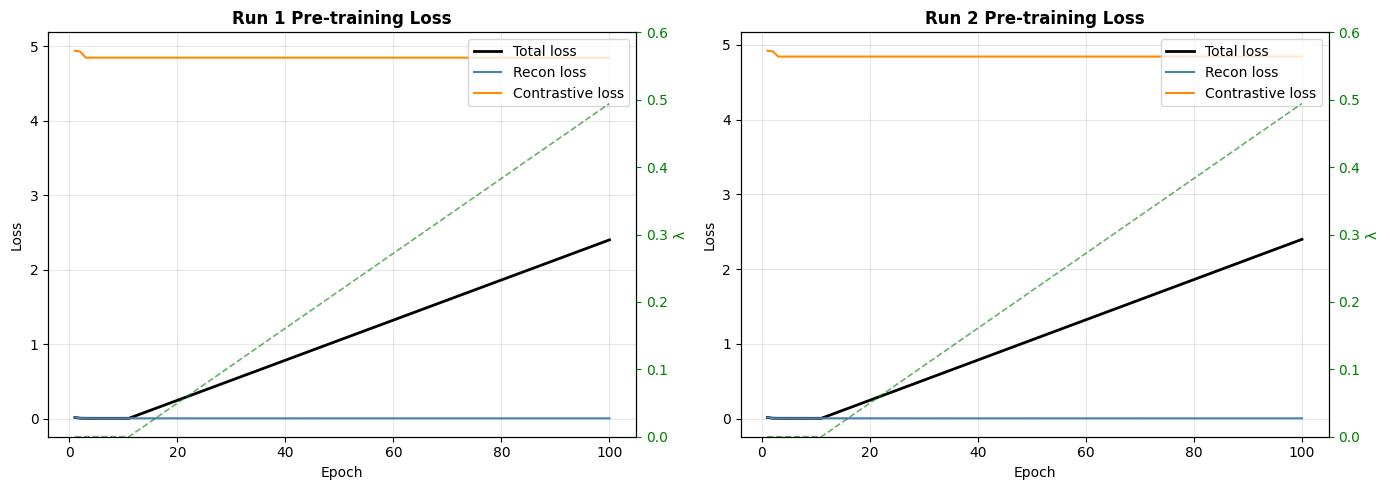

Loss curves saved.


In [62]:
fig, axes = plt.subplots(1, N_RUNS, figsize=(7 * N_RUNS, 5))
if N_RUNS == 1:
    axes = [axes]

for run_idx, run_losses in enumerate(loss_history):
    epochs    = range(1, len(run_losses) + 1)
    totals    = [x[0] for x in run_losses]
    recons    = [x[1] for x in run_losses]
    cls       = [x[2] for x in run_losses]
    lambdas   = [x[3] for x in run_losses]

    ax = axes[run_idx]
    ax.plot(epochs, totals, label='Total loss',         color='black', lw=2)
    ax.plot(epochs, recons, label='Recon loss',         color='steelblue', lw=1.5)
    ax.plot(epochs, cls,    label='Contrastive loss',   color='darkorange', lw=1.5)

    # Show lambda schedule on secondary axis
    ax2 = ax.twinx()
    ax2.plot(epochs, lambdas, '--', color='green',
             alpha=0.6, lw=1.2, label='λ (CL weight)')
    ax2.set_ylabel('λ', color='green')
    ax2.set_ylim(0, cl_max_weight * 1.2)
    ax2.tick_params(axis='y', colors='green')

    ax.set_title(f'Run {run_idx+1} Pre-training Loss',
                 fontweight='bold')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.legend(loc='upper right')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/kaggle/working/pretrain_loss_curves.png',
            dpi=200, bbox_inches='tight')
plt.show()
print("Loss curves saved.")

In [90]:
CLASS_NAMES = [
    "Background",
    "Alfalfa", "Corn-notill", "Corn-mintill", "Corn",
    "Grass-pasture", "Grass-trees", "Grass-pasture-mowed",
    "Hay-windrowed", "Oats", "Soybean-notill", "Soybean-mintill",
    "Soybean-clean", "Wheat", "Woods",
    "Buildings-Grass-Trees-Drives", "Stone-Steel-Towers"
]

CUSTOM_COLORS = [
    '#000000',  # Background

    '#8B4513',  # Alfalfa (brown)
    '#FFD700',  # Corn-notill (yellow)
    '#FFA500',  # Corn-mintill (orange)
    '#FF8C00',  # Corn (dark orange)

    '#7CFC00',  # Grass-pasture (light green)
    '#228B22',  # Grass-trees (forest green)
    '#32CD32',  # Grass-pasture-mowed

    '#ADFF2F',  # Hay-windrowed
    '#00FFFF',  # Oats (cyan)

    '#1E90FF',  # Soybean-notill (blue)
    '#4169E1',  # Soybean-mintill
    '#0000FF',  # Soybean-clean

    '#FF1493',  # Wheat (pink)
    '#A9A9A9',  # Woods (gray)

    '#FF0000',  # Buildings (red)
    '#800080'   # Towers (purple)
]

def preprocess_full_image(data_cube, pca_components):
    """Apply saved PCA + scaler for consistent inference-time transform."""
    H, W, B  = data_cube.shape
    pca      = joblib.load("/kaggle/input/datasets/sanjaykumar31/hsi-dataset/pca_model (3).pkl")
    scaler   = joblib.load("/kaggle/input/datasets/sanjaykumar31/hsi-dataset/scaler (1).pkl")
    data_pca = pca.transform(data_cube.reshape(-1, B))
    data_sc  = scaler.transform(data_pca)
    return data_sc.reshape(H, W, pca_components)


def generate_classification_map(model, data_cube, gt,
                                  patch_size, pca_components,
                                  class_num, device, batch_size=256):
    """
    Row-by-row inference — memory efficient for T4.
    Uses saved PCA + scaler (not refit) for consistency with training.
    """
    print("Step 1: Preprocessing image with saved PCA + scaler...")
    data_pca = preprocess_full_image(data_cube, pca_components)

    H, W, C = data_pca.shape
    margin  = patch_size // 2
    padded  = np.pad(data_pca,
                     ((margin, margin), (margin, margin), (0, 0)),
                     mode='reflect')

    clf_map = np.zeros(gt.shape, dtype=np.int32)
    probs   = np.zeros((*gt.shape, class_num), dtype=np.float32)

    print("Step 2: Row-by-row inference...")
    model.eval()
    with torch.no_grad():
        for i in tqdm(range(H), desc="Classifying pixels"):
            row_patches = np.array([
                padded[i:i+patch_size, j:j+patch_size, :]
                .transpose(2, 0, 1)
                for j in range(W)], dtype=np.float32)

            row_tensor = torch.from_numpy(row_patches)
            row_preds, row_probs_list = [], []

            for k in range(0, W, batch_size):
                batch = row_tensor[k:k+batch_size].to(device)
                _, out = model(batch)
                bp = torch.exp(out).cpu().numpy()
                row_preds.extend(np.argmax(bp, axis=1))
                row_probs_list.extend(bp)

            clf_map[i, :] = np.array(row_preds)
            probs[i, :, :] = np.array(row_probs_list)

    print("Classification map complete!")
    return clf_map, probs


def generate_separate_maps(clf_map, gt,
                             save_dir='/kaggle/working'):
    os.makedirs(save_dir, exist_ok=True)
    cmap   = colors.ListedColormap(CUSTOM_COLORS)
    bounds = np.arange(0, len(CUSTOM_COLORS) + 1) - 0.5
    norm   = colors.BoundaryNorm(bounds, cmap.N)

    for data, title, fname in [
        (gt,               'Ground Truth', 'ground_truth_map.png'),
        (clf_map.copy()+1, 'Prediction',   'prediction_map.png'),
    ]:
        d = data.copy()
        if fname == 'prediction_map.png':
            d[gt == 0] = 0
        fig, ax = plt.subplots(figsize=(10, 10))
        ax.imshow(d, cmap=cmap, norm=norm, interpolation='nearest')
        ax.set_title(title, fontsize=18, fontweight='bold')
        ax.axis('off')
        plt.savefig(f'{save_dir}/{fname}', dpi=300, bbox_inches='tight')
        plt.close()
        print(f"Saved {fname}")

    legend_patches = [
        Patch(color=CUSTOM_COLORS[i+1],
              label=f'{i+1}: {CLASS_NAMES[i+1]}')
        for i in range(class_num)]
    fig = plt.figure(figsize=(6, 8))
    plt.legend(handles=legend_patches, loc='center',
               ncol=2, fontsize=11, frameon=False)
    plt.axis('off')
    plt.savefig(f'{save_dir}/legend.png', dpi=300, bbox_inches='tight')
    plt.close()
    print("Saved legend.png")


def calculate_detailed_accuracy(clf_map, gt):
    mask    = gt > 0
    gt_flat = gt[mask] - 1
    pr_flat = clf_map[mask]
    results = []
    for i, name in enumerate(CLASS_NAMES[1:]):
        tp = np.sum((gt_flat == i) & (pr_flat == i))
        fp = np.sum((gt_flat != i) & (pr_flat == i))
        fn = np.sum((gt_flat == i) & (pr_flat != i))
        pr = tp / (tp + fp) if (tp + fp) > 0 else 0
        rc = tp / (tp + fn) if (tp + fn) > 0 else 0
        f1 = 2*pr*rc / (pr+rc) if (pr+rc) > 0 else 0
        results.append({
            'Class':     f'{i+1}: {name}',
            'Precision': f'{pr:.4f}',
            'Recall':    f'{rc:.4f}',
            'F1-Score':  f'{f1:.4f}',
            'Support':   int(np.sum(gt_flat == i))})
    oa = np.sum(gt_flat == pr_flat) / len(gt_flat)
    df = pd.DataFrame(results)
    print("\n=== DETAILED CLASSIFICATION REPORT ===")
    print(df.to_string(index=False))
    print(f"\nOverall Accuracy : {oa*100:.2f}%  "
          f"({len(gt_flat)} labeled pixels)")
    return df, oa

print("Visualisation utilities defined!")

Visualisation utilities defined!


In [67]:
# ===================== PAVIA UNIVERSITY BLOCK =====================

# ── Class Names ───────────────────────────────────────────────────
CLASS_NAMES = [
    "Background",
    "Asphalt", "Meadows", "Gravel", "Trees",
    "Painted metal sheets", "Bare Soil",
    "Bitumen", "Self-Blocking Bricks", "Shadows"
]

# ── Colors (10 including background) ──────────────────────────────
CUSTOM_COLORS = [
    '#000000', '#FF5733', '#33FF57', '#3357FF', '#FF33A8',
    '#A833FF', '#33FFF3', '#FFC300', '#FF8D1A', '#8DFF1A'
]

# ── Preprocessing (USE PAVIA TRAINED PCA + SCALER) ────────────────
def preprocess_full_image(data_cube, pca_components):
    """Apply saved PCA + scaler for PaviaU."""
    H, W, B = data_cube.shape

    # ⚠️ IMPORTANT: Replace with your Pavia-trained files
    pca = joblib.load("/kaggle/working/pca_model.pkl")
    scaler = joblib.load("/kaggle/working/scaler.pkl")

    data_pca = pca.transform(data_cube.reshape(-1, B))
    data_sc  = scaler.transform(data_pca)

    return data_sc.reshape(H, W, pca_components)


# ── Classification Map Generation ─────────────────────────────────
def generate_classification_map(model, data_cube, gt,
                               patch_size, pca_components,
                               class_num, device, batch_size=256):

    print("Step 1: Preprocessing image (PaviaU PCA)...")
    data_pca = preprocess_full_image(data_cube, pca_components)

    H, W, C = data_pca.shape
    margin  = patch_size // 2

    padded = np.pad(data_pca,
                    ((margin, margin), (margin, margin), (0, 0)),
                    mode='reflect')

    clf_map = np.zeros(gt.shape, dtype=np.int32)
    probs   = np.zeros((*gt.shape, class_num), dtype=np.float32)

    print("Step 2: Row-by-row inference...")
    model.eval()

    with torch.no_grad():
        for i in tqdm(range(H), desc="Classifying pixels"):
            row_patches = np.array([
                padded[i:i+patch_size, j:j+patch_size, :]
                .transpose(2, 0, 1)
                for j in range(W)
            ], dtype=np.float32)

            row_tensor = torch.from_numpy(row_patches)

            row_preds = []
            row_probs_list = []

            for k in range(0, W, batch_size):
                batch = row_tensor[k:k+batch_size].to(device)

                _, out = model(batch)
                prob = torch.exp(out).cpu().numpy()

                row_preds.extend(np.argmax(prob, axis=1))
                row_probs_list.extend(prob)

            clf_map[i, :] = np.array(row_preds)
            probs[i, :, :] = np.array(row_probs_list)

    print("✅ Classification map complete!")
    return clf_map, probs


# ── Visualization ─────────────────────────────────────────────────
def generate_separate_maps(clf_map, gt, save_dir='/kaggle/working'):

    os.makedirs(save_dir, exist_ok=True)

    cmap   = colors.ListedColormap(CUSTOM_COLORS)
    bounds = np.arange(0, len(CUSTOM_COLORS) + 1) - 0.5
    norm   = colors.BoundaryNorm(bounds, cmap.N)

    for data, title, fname in [
        (gt,               'Ground Truth', 'ground_truth_map.png'),
        (clf_map.copy()+1, 'Prediction',   'prediction_map.png'),
    ]:
        d = data.copy()

        if fname == 'prediction_map.png':
            d[gt == 0] = 0

        fig, ax = plt.subplots(figsize=(10, 10))
        ax.imshow(d, cmap=cmap, norm=norm, interpolation='nearest')
        ax.set_title(title, fontsize=18, fontweight='bold')
        ax.axis('off')

        plt.savefig(f'{save_dir}/{fname}', dpi=300, bbox_inches='tight')
        plt.close()

        print(f"Saved {fname}")

    # Legend
    legend_patches = [
        Patch(color=CUSTOM_COLORS[i+1],
              label=f'{i+1}: {CLASS_NAMES[i+1]}')
        for i in range(class_num)
    ]

    fig = plt.figure(figsize=(6, 8))
    plt.legend(handles=legend_patches,
               loc='center', ncol=2,
               fontsize=11, frameon=False)

    plt.axis('off')
    plt.savefig(f'{save_dir}/legend.png',
                dpi=300, bbox_inches='tight')
    plt.close()

    print("Saved legend.png")


# ── Accuracy Metrics ──────────────────────────────────────────────
def calculate_detailed_accuracy(clf_map, gt):

    mask    = gt > 0
    gt_flat = gt[mask] - 1
    pr_flat = clf_map[mask]

    results = []

    for i, name in enumerate(CLASS_NAMES[1:]):
        tp = np.sum((gt_flat == i) & (pr_flat == i))
        fp = np.sum((gt_flat != i) & (pr_flat == i))
        fn = np.sum((gt_flat == i) & (pr_flat != i))

        precision = tp / (tp + fp) if (tp + fp) > 0 else 0
        recall    = tp / (tp + fn) if (tp + fn) > 0 else 0
        f1        = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0

        results.append({
            'Class':     f'{i+1}: {name}',
            'Precision': f'{precision:.4f}',
            'Recall':    f'{recall:.4f}',
            'F1-Score':  f'{f1:.4f}',
            'Support':   int(np.sum(gt_flat == i))
        })

    oa = np.sum(gt_flat == pr_flat) / len(gt_flat)

    df = pd.DataFrame(results)

    print("\n=== PAVIAU CLASSIFICATION REPORT ===")
    print(df.to_string(index=False))
    print(f"\nOverall Accuracy : {oa*100:.2f}%")

    return df, oa


print("✅ PaviaU Visualization & Inference Block Ready!")

✅ PaviaU Visualization & Inference Block Ready!


In [92]:
model_inf = build_model(
    device, patch_size, class_num, encoder_depth,
    pca_components, decoder_depth,
    masking_ratio=0.00001,
    proj_dim=proj_dim,
    temperature=temperature)

model_inf.load_state_dict(
    torch.load('/kaggle/input/datasets/sanjaykumar31/hsi-dataset/net_ip_fine (1).pkl', map_location=device))
model_inf.eval()
print("Fine-tuned model loaded.")

classification_map, probabilities = generate_classification_map(
    model=model_inf, data_cube=X, gt=y,
    patch_size=patch_size, pca_components=pca_components,
    class_num=class_num, device=device, batch_size=256)

print(f"\nClassification map : {classification_map.shape}")
print(f"Probabilities      : {probabilities.shape}")

Fine-tuned model loaded.
Step 1: Preprocessing image with saved PCA + scaler...
Step 2: Row-by-row inference...


Classifying pixels: 100%|██████████| 145/145 [00:07<00:00, 19.44it/s]

Classification map complete!

Classification map : (145, 145)
Probabilities      : (145, 145, 16)


In [93]:
generate_separate_maps(classification_map, y)
results_df, final_oa = calculate_detailed_accuracy(classification_map, y)

np.savez_compressed(
    '/kaggle/working/classification_results.npz',
    classification_map=classification_map,
    probabilities=probabilities,
    ground_truth=y,
    overall_accuracy=final_oa)

results_df.to_csv(
    '/kaggle/working/classification_report.csv', index=False)

print("\n" + "="*60)
print("  PIPELINE COMPLETE")
print("="*60)
print(f"  Overall Accuracy  : {final_oa*100:.2f}%")
print(f"  Average OA        : {np.mean(OA_list)*100:.2f}% ± "
      f"{np.std(OA_list)*100:.2f}%")
print(f"  Average AA        : {np.mean(AA_list)*100:.2f}% ± "
      f"{np.std(AA_list)*100:.2f}%")
print(f"  Average Kappa     : {np.mean(Kappa_list):.4f} ± "
      f"{np.std(Kappa_list):.4f}")
print("\nSaved files:")
for f in ['ground_truth_map.png', 'prediction_map.png', 'legend.png',
          'pretrain_loss_curves.png', 'classification_results.npz',
          'classification_report.csv']:
    print(f"  /kaggle/working/{f}")

Saved ground_truth_map.png
Saved prediction_map.png
Saved legend.png

=== DETAILED CLASSIFICATION REPORT ===
                           Class Precision Recall F1-Score  Support
                      1: Alfalfa    1.0000 0.9565   0.9778       46
                  2: Corn-notill    0.9614 0.9426   0.9519     1428
                 3: Corn-mintill    0.8665 0.9855   0.9222      830
                         4: Corn    1.0000 0.9114   0.9536      237
                5: Grass-pasture    0.9704 0.9503   0.9603      483
                  6: Grass-trees    0.9611 0.9808   0.9708      730
          7: Grass-pasture-mowed    1.0000 0.8929   0.9434       28
                8: Hay-windrowed    0.9855 0.9937   0.9896      478
                         9: Oats    0.9412 0.8000   0.8649       20
              10: Soybean-notill    0.9424 0.9599   0.9511      972
             11: Soybean-mintill    0.9696 0.9609   0.9652     2455
               12: Soybean-clean    0.9791 0.9494   0.9640      593
       